# Case 2 — Designing an Interpretable Home Energy Model

## What are we trying to learn?

This case asks a model-design question rather than a method-demo question:

> **How much predictive flexibility do we need, and how much model complexity can we justify if people must repeatedly inspect and explain the model?**

We compare a sequence of increasingly flexible models:

**Baseline → Linear Regression → Lasso → Decision Tree → GAM → EBM / Pairwise Interactions → Random Forest**

The goal is not to crown one algorithm as universally “most interpretable.” Instead, we compare predictive performance with the structure a human must understand: coefficients, sparsity, rules, smooth feature functions, pairwise terms, or an ensemble.

### Connection to the lecture

The notebook reinforces three ideas:

1. **Interpretability is a design property, not just a model-family label.**
2. **Complexity should earn its place with evidence.**
3. **Evaluation design is part of explainability.** A transparent model evaluated with leakage is still misleading.

### How to use this notebook

Run top-to-bottom. Read the interpretation after each model before moving to the next one. The final decision exercise asks you to defend a model choice for a stakeholder rather than simply select the lowest RMSE.


## 1. Setup and Data

The raw dataset has already been cleaned and renamed for teaching. Instead of sensor labels such as `T1` and `RH_1`, the course dataset uses names such as `kitchen_temp_c` and `kitchen_humidity_pct`.

The first code block imports the tools used throughout the case. Notice that the notebook combines ordinary regression models from `scikit-learn` with two interpretable-model libraries used later: `pygam` for Generalized Additive Models and `interpret` for Explainable Boosting Machines.

The random seed is fixed so that model selection and train/test splitting are reproducible.

In [30]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

# Additional interpretable-model libraries used later.
from pygam import LinearGAM, s, f
from interpret.glassbox import ExplainableBoostingRegressor

RANDOM_STATE = 42

The next block loads the prepared dataset and parses the timestamp as a real datetime variable.

We first inspect only the basic structure: the number of observations, the study period, and a few example rows. We are intentionally **not** doing a large exploratory-data-analysis exercise here. Every later inspection should serve the main question about interpretable model design.

In [2]:
DATA_PATH = Path("../Data/processed/appliances_energy_course.csv")

data = pd.read_csv(
    DATA_PATH,
    parse_dates=["timestamp"],
)

print("Shape:", data.shape)
print(
    "Period:",
    data["timestamp"].min(),
    "to",
    data["timestamp"].max(),
)

display(data.head())

Shape: (19735, 31)
Period: 2016-01-11 17:00:00 to 2016-05-27 18:00:00


,timestamp,appliance_energy_wh,lights_energy_wh,kitchen_temp_c,kitchen_humidity_pct,living_room_temp_c,living_room_humidity_pct,laundry_room_temp_c,laundry_room_humidity_pct,office_temp_c,...,weather_temp_c,weather_pressure_mm_hg,weather_humidity_pct,weather_windspeed_ms,weather_visibility_km,weather_dewpoint_c,hour,day_of_week,is_weekend,random_control
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,6.600000,733.5,92.0,7.000000,63.000000,5.3,17,0,0,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,6.483333,733.6,92.0,6.666667,59.166667,5.2,17,0,0,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,6.366667,733.7,92.0,6.333333,55.333333,5.1,17,0,0,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,6.250000,733.8,92.0,6.000000,51.500000,5.0,17,0,0,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,6.133333,733.9,92.0,5.666667,47.666667,4.9,17,0,0,10.084097


### What do we know so far?

The dataset contains **19,735 observations** collected from January to May 2016. Each row represents one 10-minute measurement period.

Before interpreting any model, always be clear about what one row represents and what the target means. A technically correct model can still be conceptually misleading if the prediction task itself is poorly defined.

**Key idea:** Explainability starts with a clear problem formulation, not with an explanation plot.

## 2. Understand the Target and the Evaluation Metric

Our target is `appliance_energy_wh`: appliance energy use in watt-hours for each 10-minute observation.

Before fitting a model, we inspect the target distribution. This matters because the shape of the target affects how error metrics behave. Household energy use contains many ordinary low-consumption periods and a smaller number of much larger consumption events.

We will use three metrics:

- **MAE** — average absolute prediction error. It answers: *How far off are predictions on average?*
- **RMSE** — also measures prediction error, but large mistakes receive more weight.
- **R²** — compares the model with a constant mean prediction. A value of 0 means the model is doing roughly no better than predicting the mean; it is **not** an “accuracy percentage.”

For this case, **RMSE is the primary model-selection metric** because we want large errors to matter. MAE and R² remain useful secondary views.

The block below also checks the correlation between the target and `random_control`. This variable is intentionally meaningless and will later act as a **negative control**: if a flexible model learns a very strong pattern from it, we should become suspicious.

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: appliance_energy_wh, dtype: float64

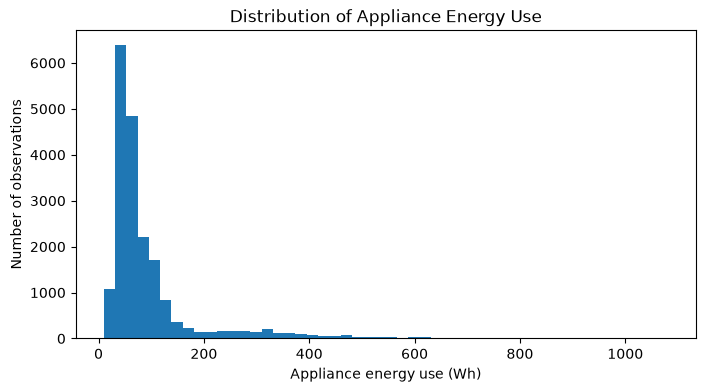

Random-control correlation with target: -0.011


In [3]:
TARGET = "appliance_energy_wh"

display(data[TARGET].describe())

plt.figure(figsize=(8, 4))
plt.hist(data[TARGET], bins=50)
plt.xlabel("Appliance energy use (Wh)")
plt.ylabel("Number of observations")
plt.title("Distribution of Appliance Energy Use")
plt.show()

print(
    "Random-control correlation with target:",
    round(data[TARGET].corr(data["random_control"]), 3),
)

### Result interpretation

The target is strongly right-skewed: the median is much lower than the mean, while a few observations reach very high energy use.

The correlation between `random_control` and the target is approximately **−0.011**, which is essentially zero. That is what we hope to see from a deliberately meaningless feature.

This does **not** guarantee that every model will completely ignore it. With finite data, flexible models can still fit small accidental patterns to noise.

**Key idea:** A visible learned pattern is not automatically a meaningful real-world relationship.

## 3. Design a Fair Evaluation

### Why not randomly split individual rows?

Measurements are recorded every 10 minutes, so nearby observations are related. A simple random row split could place measurements from the same day in both the training and test sets, making the evaluation easier than the intended real-world generalization question.

Instead, we split the data by **whole calendar days**. All observations from one day stay together.

We also remove `day_of_week` while keeping `is_weekend`, because weekend status is already determined by day of week. Keeping both would provide overlapping calendar information.

We deliberately **do not remove correlated temperature and humidity sensors**. Their redundancy becomes useful later when we discuss coefficient interpretation and sparse feature selection.

The next block creates the grouped train/test split. The test days are kept untouched while model choices are made using grouped cross-validation inside the training set.

In [4]:
# Keep the same underlying information for all model families.
MODEL_FEATURES = [
    column
    for column in data.columns
    if column not in ["timestamp", TARGET, "day_of_week"]
]

X = data[MODEL_FEATURES].copy()
y = data[TARGET].copy()

# Group rows by calendar day.
date_groups = data["timestamp"].dt.date

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=date_groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_groups = date_groups.iloc[train_idx]

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))
print("Training days:", train_groups.nunique())
print("Test days:", date_groups.iloc[test_idx].nunique())

Training observations: 15703
Test observations: 4032
Training days: 110
Test days: 28


### Split result

The split contains **110 training days** and **28 test days**, with 15,703 and 4,032 observations respectively.

The important point is not the exact numbers. The important point is that one calendar day cannot be partially present in both training and test data.

**Technical takeaway:** Evaluation design is part of explainable data science. A transparent model evaluated with leakage can still give us misleading confidence.

### Establish a baseline before fitting a model

A model result is only meaningful relative to something simpler.

The first baseline predicts the **training-set mean** for every test observation. The mean is the natural constant baseline for squared error, so it aligns with our primary metric, RMSE.

We also calculate a median baseline once. The median minimizes absolute error, so comparing the two baselines helps demonstrate that “best performance” depends on the metric being optimized.

In [5]:
def regression_metrics(y_true, y_pred):
    """Return the three metrics used throughout the notebook."""
    return pd.Series({
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R²": r2_score(y_true, y_pred),
    })


# Mean is optimal for squared-error loss.
mean_baseline_pred = np.full(
    len(y_test),
    y_train.mean(),
)

# Median is optimal for absolute-error loss.
median_baseline_pred = np.full(
    len(y_test),
    y_train.median(),
)

mean_baseline_results = regression_metrics(
    y_test,
    mean_baseline_pred,
)

median_baseline_results = regression_metrics(
    y_test,
    median_baseline_pred,
)

baseline_comparison = pd.DataFrame({
    "Mean baseline": mean_baseline_results,
    "Median baseline": median_baseline_results,
}).T

display(baseline_comparison.round(3))

,MAE,RMSE,R²
Mean baseline,61.341,104.325,-0.001
Median baseline,52.264,111.634,-0.146


### Baseline interpretation

The mean baseline gives approximately:

- **MAE = 61.34 Wh**
- **RMSE = 104.33 Wh**
- **R² ≈ 0**

The median baseline has a better MAE but a worse RMSE. This is not a contradiction. The two constants optimize different loss functions.

From this point onward, the mean baseline RMSE of about **104 Wh** is our main reference.

**Key idea:** Never discuss model performance without first defining what “better” means and what baseline the model is being compared with.

## 4. Linear Regression — Start Simple

Linear Regression is important in this lecture for two reasons: it is both a **performance baseline** and an **intrinsically interpretable model**.

A linear model represents the prediction as:

\[
\hat{y} = \beta_0 + \beta_1x_1 + \cdots + \beta_px_p
\]

Each feature receives one coefficient. In plain language, the model assumes that each feature contributes through one constant slope.

### One technical problem: hour is circular

The raw values `0, 1, ..., 23` are not naturally linear. In real time, 23:00 and 00:00 are neighbors, but numerically 23 and 0 appear far apart.

For the linear models only, the next block replaces raw hour with sine and cosine coordinates. This gives Linear Regression a sensible representation of daily periodicity without changing the model family itself.

> **Think first:** If a transparent linear model already performs reasonably well, how large should the improvement from a more complex model be before complexity is justified?

In [6]:
def encode_cyclic_hour(frame):
    """Replace raw hour with sine/cosine coordinates on a 24-hour cycle."""
    encoded = frame.copy()

    hour = encoded.pop("hour")

    encoded["hour_sin"] = np.sin(
        2 * np.pi * hour / 24
    )
    encoded["hour_cos"] = np.cos(
        2 * np.pi * hour / 24
    )

    return encoded


X_train_linear = encode_cyclic_hour(X_train)
X_test_linear = encode_cyclic_hour(X_test)

The next block creates a pipeline with two steps:

1. `StandardScaler` puts numeric inputs onto comparable scales.
2. `LinearRegression` fits the coefficients.

Standardization is useful here because we later compare coefficient magnitudes. It does **not** make coefficients causal or automatically stable.

In [7]:
linear_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LinearRegression()),
])

linear_model.fit(
    X_train_linear,
    y_train,
)

linear_predictions = linear_model.predict(
    X_test_linear
)

linear_results = regression_metrics(
    y_test,
    linear_predictions,
)

display(
    pd.DataFrame({
        "Mean baseline": mean_baseline_results,
        "Linear Regression": linear_results,
    }).T.round(3)
)

,MAE,RMSE,R²
Mean baseline,61.341,104.325,-0.001
Linear Regression,53.887,94.369,0.181


### Linear Regression result

The model achieves approximately:

- **MAE = 53.89 Wh**
- **RMSE = 94.37 Wh**
- **R² = 0.181**

Compared with the mean-baseline RMSE of about 104.33, this is a meaningful improvement.

That result is important because we have not yet introduced nonlinear curves, tree interactions, boosting, or ensembles. A relatively simple and globally inspectable model already captures useful predictive structure.

The correct conclusion is **not** that the real household behaves linearly. The safer conclusion is that a linear approximation already explains useful variation in this prediction task.

### Inspect the coefficients

Because the predictors were standardized, the coefficient magnitudes are easier to compare.

A positive coefficient means that, **inside this fitted model and holding the other model inputs fixed**, higher values of that term contribute toward larger predictions. A negative coefficient contributes in the opposite direction.

Be careful with that sentence. Correlated sensors can split predictive signal between each other, produce unstable coefficients, or even lead to counterintuitive signs.

Therefore, say:

> “The model relies strongly on this term.”

Do **not** automatically say:

> “This feature causes energy consumption to change.”

,standardized_coefficient
living_room_humidity_pct,-52.326768
living_room_temp_c,-43.679837
parents_room_temp_c,-39.279352
hour_cos,-26.913884
weather_temp_c,-24.327059
hour_sin,-14.281440
teen_room_temp_c,13.137153
laundry_room_humidity_pct,15.555173
lights_energy_wh,15.633918
weather_dewpoint_c,24.784546


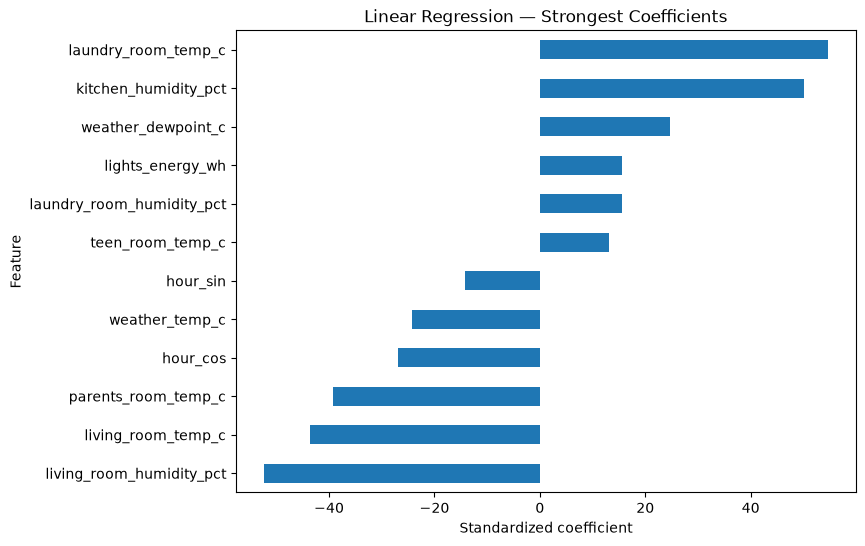

Random-control coefficient: -0.182


In [8]:
linear_coefficients = pd.Series(
    linear_model.named_steps["model"].coef_,
    index=X_train_linear.columns,
)

top_linear = (
    linear_coefficients
    .reindex(
        linear_coefficients.abs()
        .sort_values(ascending=False)
        .head(12)
        .index
    )
    .sort_values()
)

display(
    top_linear
    .rename("standardized_coefficient")
    .to_frame()
)

plt.figure(figsize=(8, 6))
top_linear.plot(kind="barh")
plt.xlabel("Standardized coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression — Strongest Coefficients")
plt.show()

print(
    "Random-control coefficient:",
    round(linear_coefficients["random_control"], 3),
)

### What should you notice?

The `random_control` coefficient is very small relative to the stronger terms, which is reassuring.

But the coefficient table also exposes an important limitation of “interpretable” linear models: a model with many coefficients can still become cognitively difficult to inspect.

This motivates our next question.

**Key takeaway:** Linear Regression is transparent in structure, but interpretability also depends on how many components a person must reason about.

## 5. Lasso — Make Simplicity Part of the Objective

Lasso keeps the linear model structure but adds an L1 penalty:

\[
\text{Loss} + \lambda\sum_j |\beta_j|
\]

As the regularization strength increases, coefficients are shrunk toward zero and some become exactly zero.

This introduces one of the lecture's main ideas:

> **Interpretability can be treated as a design objective, not just something we inspect after training.**

A sparse model may be easier to explain because fewer features remain active.

But sparsity is not free. Stronger regularization can also remove useful predictive information.

### Why use a pipeline and grouped cross-validation?

The scaler must be fitted separately inside each training fold. If scaling were performed before cross-validation, information from validation folds would leak into preprocessing.

The next block therefore tunes Lasso as a complete pipeline using `GroupKFold`, keeping observations from the same day in the same fold.

In [9]:
group_cv = GroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

lasso_search = GridSearchCV(
    estimator=Pipeline([
        ("scale", StandardScaler()),
        ("model", Lasso(max_iter=50_000)),
    ]),
    param_grid={
        "model__alpha": np.logspace(-2, 2, 40),
    },
    scoring="neg_root_mean_squared_error",
    cv=group_cv,
    n_jobs=-1,
)

lasso_search.fit(
    X_train_linear,
    y_train,
    groups=train_groups,
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=50000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'model__alpha': array([1.0000...00000000e+02])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

### Two ways to choose regularization

The numerically best validation model is not necessarily the model we want if interpretability matters.

We therefore compare:

- **CV-optimal Lasso** — the `alpha` with the lowest mean validation RMSE.
- **One-standard-error Lasso** — among models statistically close to the best result, choose the stronger penalty and therefore the simpler model.

Larger `alpha` means stronger regularization and usually more coefficients being pushed to zero.

This is a concrete version of the principle:

> **If two models perform similarly, prefer the simpler one when simplicity matters to the decision context.**

In [10]:
lasso_cv = pd.DataFrame(
    lasso_search.cv_results_
)

lasso_cv["alpha"] = (
    lasso_cv["param_model__alpha"]
    .astype(float)
)

lasso_cv["mean_cv_rmse"] = (
    -lasso_cv["mean_test_score"]
)

lasso_cv["se_cv_rmse"] = (
    lasso_cv["std_test_score"]
    / np.sqrt(group_cv.get_n_splits())
)

best_row = lasso_cv.loc[
    lasso_cv["mean_cv_rmse"].idxmin()
]

one_se_threshold = (
    best_row["mean_cv_rmse"]
    + best_row["se_cv_rmse"]
)

# Among statistically similar models, choose the strongest penalty.
one_se_alpha = (
    lasso_cv.loc[
        lasso_cv["mean_cv_rmse"] <= one_se_threshold,
        "alpha",
    ]
    .max()
)

print(
    "CV-optimal alpha:",
    round(best_row["alpha"], 4),
)

print(
    "One-SE alpha:",
    round(one_se_alpha, 4),
)

CV-optimal alpha: 0.1701
One-SE alpha: 7.4438


With the fixed split used here, the CV-optimal `alpha` is about **0.17**, while the one-standard-error choice is much stronger at about **7.44**.

The next block fits both versions on all training days and compares their held-out performance and the number of active features.

In [11]:
# Fit both choices on all training days.
lasso_best = lasso_search.best_estimator_

lasso_sparse = Pipeline([
    ("scale", StandardScaler()),
    ("model", Lasso(
        alpha=one_se_alpha,
        max_iter=50_000,
    )),
])

lasso_sparse.fit(
    X_train_linear,
    y_train,
)


def active_feature_count(model):
    coefficients = model.named_steps["model"].coef_
    return int(
        np.sum(np.abs(coefficients) > 1e-8)
    )


lasso_best_results = regression_metrics(
    y_test,
    lasso_best.predict(X_test_linear),
)

lasso_sparse_results = regression_metrics(
    y_test,
    lasso_sparse.predict(X_test_linear),
)

lasso_comparison = pd.DataFrame({
    "CV-optimal Lasso": {
        **lasso_best_results.to_dict(),
        "Active features": active_feature_count(lasso_best),
    },
    "One-SE Lasso": {
        **lasso_sparse_results.to_dict(),
        "Active features": active_feature_count(lasso_sparse),
    },
}).T

display(lasso_comparison.round(3))

,MAE,RMSE,R²,Active features
CV-optimal Lasso,53.350,94.116,0.186,25.0
One-SE Lasso,53.323,97.442,0.127,5.0


### Lasso result interpretation

The **CV-optimal Lasso** keeps **25 active features** and reaches approximately **RMSE 94.12**.

The **one-standard-error Lasso** keeps only **5 active features**, but RMSE increases to approximately **97.44**.

This is one of the most useful results in the notebook.

We have dramatically reduced the number of active terms, making the model easier to inspect, but we paid for that simplicity with somewhat worse prediction on large errors.

Notice that MAE changes very little while RMSE worsens more clearly. This suggests that the sparse model remains reasonable for many ordinary observations but makes some larger mistakes that RMSE penalizes heavily.

> **Decision question:** If you had to explain the model repeatedly to a building-energy analyst, would reducing the explanation from 25 active features to 5 be worth this loss in RMSE?

The next block shows which coefficients remain active in the sparse model.

Remember that Lasso selection can be unstable when predictors are highly correlated. A feature receiving a zero coefficient does not mean it is irrelevant to the real physical system; it means this fitted sparse model did not need that feature given the other available predictors.

,standardized_coefficient
hour_cos,-15.911282
hour_sin,-13.601689
kitchen_humidity_pct,0.640528
laundry_room_temp_c,1.404660
lights_energy_wh,10.650263


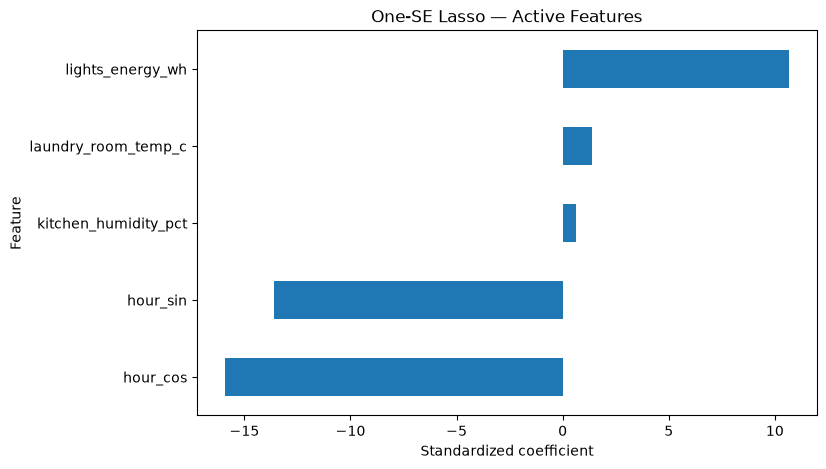

Random control retained: False


In [12]:
sparse_coefficients = pd.Series(
    lasso_sparse.named_steps["model"].coef_,
    index=X_train_linear.columns,
)

active_sparse = sparse_coefficients[
    sparse_coefficients.abs() > 1e-8
].sort_values()

display(
    active_sparse
    .rename("standardized_coefficient")
    .to_frame()
)

plt.figure(figsize=(8, 5))
active_sparse.plot(kind="barh")
plt.xlabel("Standardized coefficient")
plt.ylabel("Feature")
plt.title("One-SE Lasso — Active Features")
plt.show()

print(
    "Random control retained:",
    "random_control" in active_sparse.index,
)

The meaningless `random_control` feature is removed completely by the sparse model, which is a useful sanity check.

**Key takeaway:** Sparsity can improve human manageability, but fewer features do not automatically mean a better model. The appropriate level of sparsity depends on the performance cost and the stakeholder's need for simplicity.

## 6. Decision Tree — Interpretable Rules, Until the Tree Becomes Too Large

Decision Trees replace linear coefficients with hierarchical rules.

A path through a tree can be read conceptually as:

**if condition → follow branch → test another condition → reach a prediction**

This makes trees attractive for human reasoning. They can also represent nonlinear thresholds and interactions naturally.

However, the lecture's deeper point is that **a transparent model class does not guarantee a cognitively manageable fitted model**.

A depth-3 tree may be easy to simulate mentally. A 200-leaf tree is a very different object.

### Select a tree inside a reasonable complexity budget

The next block searches only over relatively small tree depths and minimum leaf sizes using grouped cross-validation.

`max_depth` limits how many sequential decisions can occur.

`min_samples_leaf` prevents the model from creating tiny highly specific leaves. Increasing it acts as regularization and can also make the tree easier to inspect.

In [13]:
tree_search = GridSearchCV(
    estimator=DecisionTreeRegressor(
        random_state=RANDOM_STATE
    ),
    param_grid={
        "max_depth": [2, 3, 4, 5],
        "min_samples_leaf": [50, 100, 200, 300],
    },
    scoring="neg_root_mean_squared_error",
    cv=group_cv,
    n_jobs=-1,
)

tree_search.fit(
    X_train,
    y_train,
    groups=train_groups,
)

small_tree = tree_search.best_estimator_

small_tree_predictions = small_tree.predict(
    X_test
)

small_tree_results = regression_metrics(
    y_test,
    small_tree_predictions,
)

print("Selected parameters:", tree_search.best_params_)
print("Tree depth:", small_tree.get_depth())
print("Leaves:", small_tree.get_n_leaves())

display(
    small_tree_results
    .rename("Small Tree")
    .to_frame()
    .T
    .round(3)
)

Selected parameters: {'max_depth': 5, 'min_samples_leaf': 300}
Tree depth: 5
Leaves: 20


,MAE,RMSE,R²
Small Tree,49.981,95.34,0.164


### Selected tree

Grouped validation selects a tree with:

- **depth = 5**
- **20 leaves**
- **minimum leaf size = 300**

Its test performance is approximately:

- **MAE = 49.98 Wh**
- **RMSE = 95.34 Wh**
- **R² = 0.164**

Notice an important metric difference: the tree has a better MAE than Linear Regression but a slightly worse RMSE.

So which model is “better”? The answer depends on whether we care more about the typical error or larger mistakes.

The next plot shows the actual rule structure. Try to follow one path from the root to a leaf. Even at only 20 leaves, ask yourself how much of the whole tree you could realistically keep in your head.

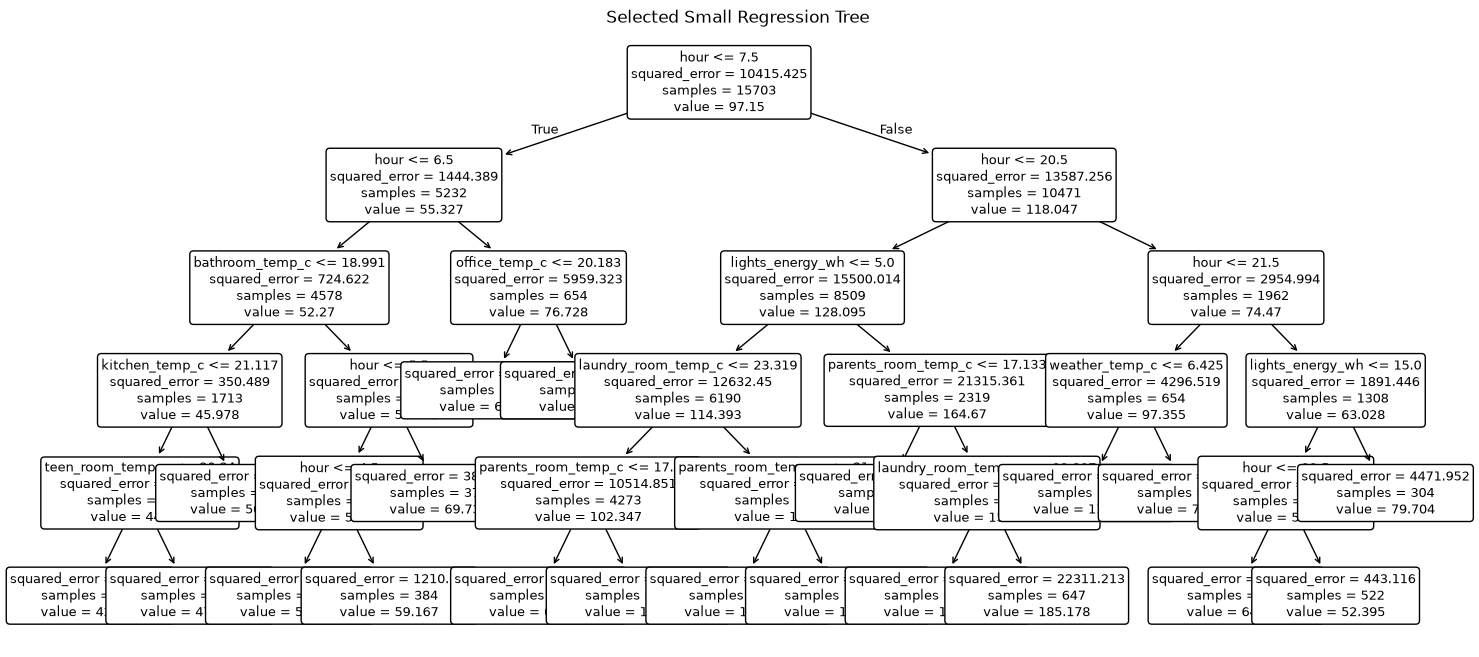

In [14]:
plt.figure(figsize=(18, 8))

plot_tree(
    small_tree,
    feature_names=X_train.columns,
    filled=False,
    rounded=True,
    fontsize=9,
)

plt.title("Selected Small Regression Tree")
plt.show()

### What does interpretability mean here?

A tree is **decomposable** because each split can be inspected.

But **simulatability** becomes harder as the tree grows. Being able to print the full tree is not the same as being able to understand the full decision process.

Now we deliberately make the tree much larger. This is not an attempt to improve the final model. It is an experiment in both statistical and cognitive complexity.

> **Predict first:** What do you expect to happen to training error? What about test error? What happens to human readability?

In [15]:
# Deliberately allow much more tree complexity.
large_tree = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
)

large_tree.fit(
    X_train,
    y_train,
)

tree_diagnostic = pd.DataFrame({
    "Small Tree — Train": regression_metrics(
        y_train,
        small_tree.predict(X_train),
    ),
    "Small Tree — Test": regression_metrics(
        y_test,
        small_tree.predict(X_test),
    ),
    "Large Tree — Train": regression_metrics(
        y_train,
        large_tree.predict(X_train),
    ),
    "Large Tree — Test": regression_metrics(
        y_test,
        large_tree.predict(X_test),
    ),
}).T

display(tree_diagnostic.round(3))

print(
    "Large-tree depth:",
    large_tree.get_depth(),
)

print(
    "Large-tree leaves:",
    large_tree.get_n_leaves(),
)

,MAE,RMSE,R²
Small Tree — Train,49.356,91.663,0.193
Small Tree — Test,49.981,95.340,0.164
Large Tree — Train,40.002,78.709,0.405
Large Tree — Test,53.699,102.057,0.042


Large-tree depth: 10
Large-tree leaves: 222


### Large-tree result

The large tree reaches **depth 10 with 222 leaves**.

Its training RMSE improves dramatically to about **78.71**, but test RMSE deteriorates to about **102.06**. Test R² falls to about **0.042**.

Two problems appear at the same time:

1. **Statistical overfitting** — the model learns training-specific patterns that do not generalize well.
2. **Cognitive overload** — 222 leaves may technically be visible, but the model is no longer realistically human-simulatable.

**Key takeaway:** “Decision Tree” is not itself a guarantee of interpretability. Model size and cognitive complexity matter.

## 7. Generalized Additive Model — Nonlinear, but Still Globally Inspectable

Linear Regression gives each feature one constant slope:

\[
\beta_jx_j
\]

A Generalized Additive Model (GAM) replaces that slope with a learned function:

\[
f_j(x_j)
\]

The complete model remains additive:

\[
\hat{y} = \beta_0 + f_1(x_1) + f_2(x_2) + \cdots + f_p(x_p)
\]

In plain language:

> **Linear Regression learns one line per feature. GAM learns one curve per feature.**

This is an important middle ground in the lecture. We gain nonlinear predictive flexibility while keeping each feature-level function directly inspectable.

The next block defines the GAM structure. Most continuous features receive smooth spline terms. `hour` receives a cyclic spline because the day repeats every 24 hours, while `is_weekend` is handled as a factor term.

The `lam` parameter controls smoothness:

- smaller values allow more flexible, wiggly curves,
- larger values impose stronger smoothing and produce simpler functions.

In [16]:
GAM_FEATURES = list(X_train.columns)

feature_index = {
    feature: i
    for i, feature in enumerate(GAM_FEATURES)
}


def build_gam(lam):
    """Create a GAM with one interpretable term per feature."""
    terms = None

    for i, feature in enumerate(GAM_FEATURES):

        if feature == "hour":
            # Hour repeats every 24 hours.
            term = s(
                i,
                n_splines=12,
                basis="cp",
            )

        elif feature == "is_weekend":
            # Binary indicator.
            term = f(i)

        else:
            # Smooth effect for continuous measurements.
            term = s(
                i,
                n_splines=10,
            )

        terms = (
            term
            if terms is None
            else terms + term
        )

    return LinearGAM(
        terms,
        lam=lam,
    )

### Select smoothness with grouped cross-validation

A highly flexible GAM can fit noise just as a large tree can.

The next block compares several smoothing strengths. For each candidate, we record:

- **CV RMSE** — predictive error on validation days,
- **SE RMSE** — uncertainty in that cross-validation estimate,
- **Mean EDoF** — effective degrees of freedom, a practical indicator of model complexity.

We again use a one-standard-error idea: if several models perform close enough to the best result, prefer the simpler one.

This keeps the same principle consistent across Lasso and GAM:

> **Complexity should earn its place.**

In [17]:
gam_cv = GroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

candidate_lams = [
    5,
    20,
    100,
    500,
    2000,
]

gam_rows = []

for lam in candidate_lams:

    fold_rmse = []
    fold_edof = []

    for train_pos, val_pos in gam_cv.split(
        X_train,
        y_train,
        groups=train_groups,
    ):
        model = build_gam(lam)

        model.fit(
            X_train.iloc[train_pos].values,
            y_train.iloc[train_pos].values,
        )

        val_predictions = model.predict(
            X_train.iloc[val_pos].values
        )

        fold_rmse.append(
            mean_squared_error(
                y_train.iloc[val_pos],
                val_predictions,
            ) ** 0.5
        )

        fold_edof.append(
            model.statistics_["edof"]
        )

    gam_rows.append({
        "lambda": lam,
        "CV_RMSE": np.mean(fold_rmse),
        "SE_RMSE": (
            np.std(
                fold_rmse,
                ddof=1,
            )
            / np.sqrt(len(fold_rmse))
        ),
        "Mean_EDoF": np.mean(fold_edof),
    })


gam_tuning = pd.DataFrame(gam_rows)

display(
    gam_tuning.round(2)
)

,lambda,CV_RMSE,SE_RMSE,Mean_EDoF
0,5,96.23,3.05,148.18
1,20,95.01,3.05,118.08
2,100,93.48,3.14,85.34
3,500,92.50,3.30,59.57
4,2000,92.53,3.40,44.51


The next block applies the one-standard-error rule and selects the eligible GAM with the lowest effective complexity.

In [18]:
best_gam_row = gam_tuning.loc[
    gam_tuning["CV_RMSE"].idxmin()
]

gam_one_se_threshold = (
    best_gam_row["CV_RMSE"]
    + best_gam_row["SE_RMSE"]
)

eligible_gams = gam_tuning[
    gam_tuning["CV_RMSE"]
    <= gam_one_se_threshold
]

# Prefer the eligible model with the lowest effective complexity.
selected_gam_row = (
    eligible_gams
    .sort_values("Mean_EDoF")
    .iloc[0]
)

selected_lambda = float(
    selected_gam_row["lambda"]
)

print(
    "Selected lambda:",
    selected_lambda,
)

print(
    "Estimated CV RMSE:",
    round(
        selected_gam_row["CV_RMSE"],
        2,
    ),
)

print(
    "Mean effective degrees of freedom:",
    round(
        selected_gam_row["Mean_EDoF"],
        2,
    ),
)

Selected lambda: 2000.0
Estimated CV RMSE: 92.53
Mean effective degrees of freedom: 44.51


### GAM smoothness result

The selected smoothing penalty is **λ = 2000**.

Its grouped-validation RMSE is approximately **92.53**, with mean effective degrees of freedom around **44.5**.

The relatively strong smoothing is informative. Validation did not reward extremely flexible, highly wiggly functions.

The next block fits the selected GAM on all training days and evaluates it once on the untouched test days.

In [19]:
gam_model = build_gam(
    selected_lambda
)

gam_model.fit(
    X_train.values,
    y_train.values,
)

gam_predictions = gam_model.predict(
    X_test.values
)

gam_results = regression_metrics(
    y_test,
    gam_predictions,
)

display(
    gam_results
    .rename("GAM")
    .to_frame()
    .T
    .round(3)
)

print(
    "Final effective degrees of freedom:",
    round(
        gam_model.statistics_["edof"],
        2,
    ),
)

negative_predictions = int(
    np.sum(gam_predictions < 0)
)

print(
    "Negative predictions:",
    negative_predictions,
)

print(
    "Prediction range:",
    round(gam_predictions.min(), 2),
    "to",
    round(gam_predictions.max(), 2),
)

,MAE,RMSE,R²
GAM,51.594,91.971,0.222


Final effective degrees of freedom: 47.96
Negative predictions: 5
Prediction range: -9.76 to 389.63


### GAM test result

The GAM achieves approximately:

- **MAE = 51.59 Wh**
- **RMSE = 91.97 Wh**
- **R² = 0.222**

Its RMSE improves over Linear Regression, suggesting that nonlinear feature-level structure adds predictive value beyond a single constant slope.

But notice a second result: the model produces **5 negative predictions**, with a minimum around **−9.76 Wh**.

Appliance energy cannot physically be negative.

We deliberately do **not** silently clip these values to zero. The invalid predictions expose a useful limitation:

> **Interpretability helps us inspect model behavior; it does not guarantee that the behavior obeys domain constraints.**

A production model might require a different response distribution, target transformation, explicit constraint, or justified post-processing step.

### Inspect the learned feature shapes

One of GAM's main advantages is that we can inspect each learned function directly.

For a shape plot:

- the horizontal axis is the feature value,
- the vertical axis is that feature's contribution to the model prediction.

Look for curvature, thresholds, plateaus, and changes in slope.

Do **not** interpret the curve as an intervention effect. It tells us how this fitted model uses the feature under the observed data and model assumptions.

The next block plots only a few representative features so that the explanation remains cognitively manageable.

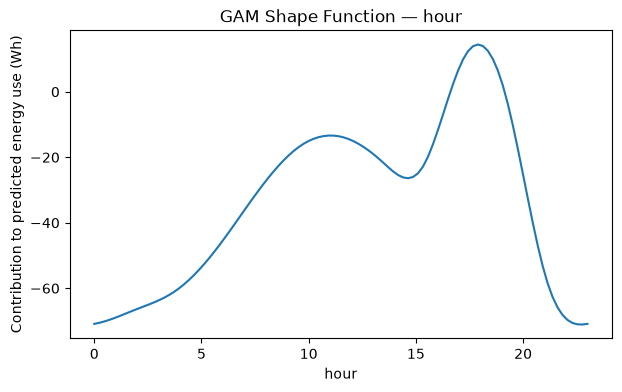

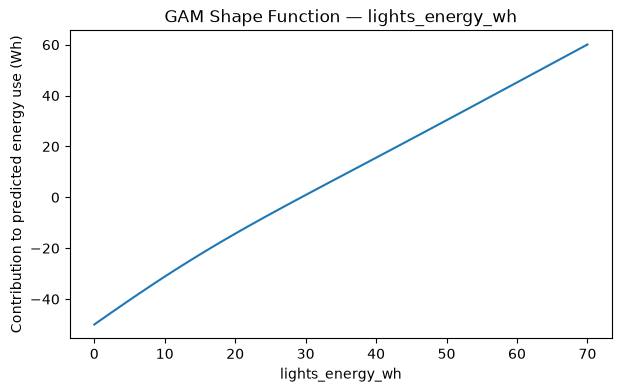

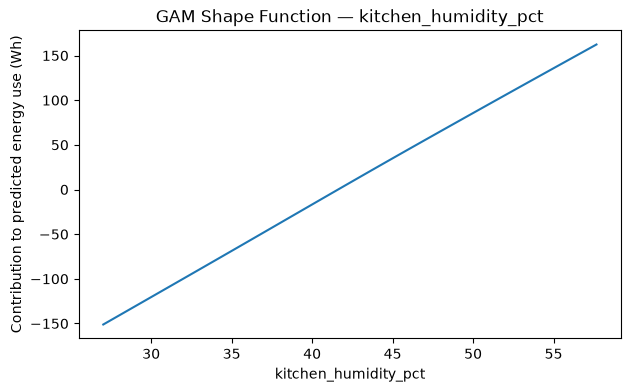

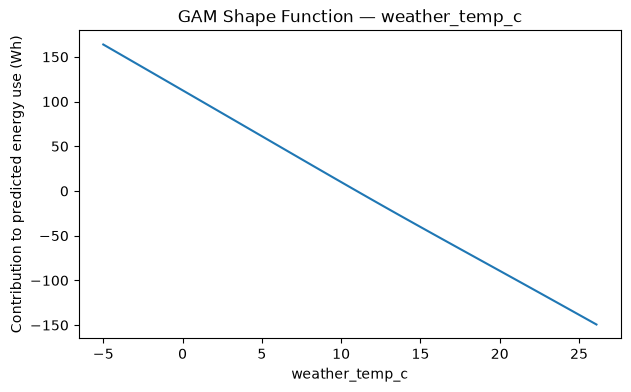

In [20]:
features_to_plot = [
    "hour",
    "lights_energy_wh",
    "kitchen_humidity_pct",
    "weather_temp_c",
]

for feature in features_to_plot:

    idx = feature_index[feature]

    XX = gam_model.generate_X_grid(
        term=idx
    )

    effect = gam_model.partial_dependence(
        term=idx,
        X=XX,
    )

    plt.figure(figsize=(7, 4))

    plt.plot(
        XX[:, idx],
        effect,
    )

    plt.xlabel(feature)
    plt.ylabel(
        "Contribution to predicted energy use (Wh)"
    )
    plt.title(
        f"GAM Shape Function — {feature}"
    )

    plt.show()

### How should you read the plots?

If a curve rises sharply in one region, the model is assigning larger predicted energy contributions there. If it flattens, the contribution changes little across that range.

Focus more on the **shape and variation** than the absolute vertical position of one term, because the final prediction also contains the intercept and all other feature contributions.

The correct statement is:

> “The fitted GAM learned this predictive shape.”

The stronger statement:

> “Changing this feature will cause energy use to follow this curve.”

is **not justified** by this analysis.

### Negative-control check

We now inspect the GAM function learned for `random_control`.

A flexible model may still fit small accidental patterns to random noise, so we should not demand a mathematically perfect flat line.

Instead ask:

> Is the learned variation small relative to meaningful effects and the scale of the target?

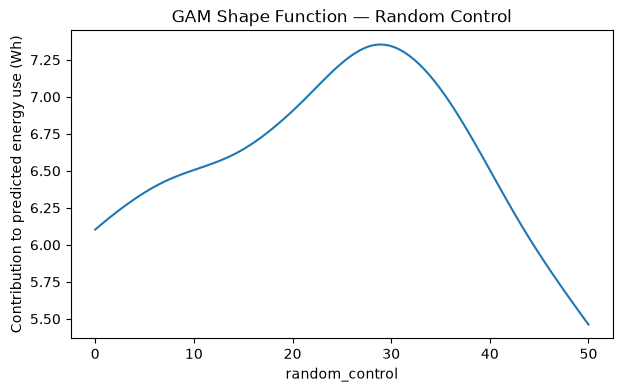

Random-control effect variation: 1.89 Wh


In [21]:
feature = "random_control"
idx = feature_index[feature]

XX = gam_model.generate_X_grid(
    term=idx
)

random_effect = gam_model.partial_dependence(
    term=idx,
    X=XX,
)

plt.figure(figsize=(7, 4))

plt.plot(
    XX[:, idx],
    random_effect,
)

plt.xlabel(feature)
plt.ylabel(
    "Contribution to predicted energy use (Wh)"
)
plt.title(
    "GAM Shape Function — Random Control"
)

plt.show()

print(
    "Random-control effect variation:",
    round(
        random_effect.max()
        - random_effect.min(),
        2,
    ),
    "Wh",
)

The random-control function varies by only about **1.89 Wh**, which is relatively small.

This is reassuring, but the curve is not perfectly flat. That is itself an important lesson:

> **Even an interpretable model can display a visible pattern for meaningless noise.**

Interpretability gives us access to the learned structure. Human judgment is still needed to decide whether that structure deserves meaning.

**GAM takeaway:** We gained useful nonlinear flexibility while preserving feature-level inspection, but we still had to control smoothness, check noise behavior, avoid causal claims, and notice physically invalid predictions.

## 8. Pairwise Interactions — Does Extra Flexibility Earn Its Place?

A standard GAM assumes that feature effects add independently:

\[
\hat{y} = \beta_0 + \sum_j f_j(x_j)
\]

A GA2M-style model can add selected pairwise functions:

\[
\hat{y} = \beta_0 + \sum_j f_j(x_j) + \sum_{j,k} f_{jk}(x_j,x_k)
\]

An interaction means that the contribution associated with one feature depends on the value of another.

This sounds more flexible, but the lecture makes an important point: **do not include interactions automatically**. With many features there are many possible pairs, so interactions should be retained only when they add validated value.

We use an Explainable Boosting Machine (EBM) as a practical interpretable interaction learner.

The next block compares an EBM with no pairwise interactions against one allowed to add five interactions, using grouped cross-validation.

> **Predict first:** Does giving the model more interaction terms guarantee better validation performance?

In [22]:
ebm_cv = GroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

interaction_options = [
    0,
    5,
]

ebm_rows = []

for interaction_count in interaction_options:

    fold_rmse = []

    for train_pos, val_pos in ebm_cv.split(
        X_train,
        y_train,
        groups=train_groups,
    ):
        model = ExplainableBoostingRegressor(
            interactions=interaction_count,
            random_state=RANDOM_STATE,
        )

        model.fit(
            X_train.iloc[train_pos],
            y_train.iloc[train_pos],
        )

        val_predictions = model.predict(
            X_train.iloc[val_pos]
        )

        fold_rmse.append(
            mean_squared_error(
                y_train.iloc[val_pos],
                val_predictions,
            ) ** 0.5
        )

    ebm_rows.append({
        "Interactions": interaction_count,
        "CV_RMSE": np.mean(fold_rmse),
        "SE_RMSE": (
            np.std(
                fold_rmse,
                ddof=1,
            )
            / np.sqrt(len(fold_rmse))
        ),
    })


ebm_cv_results = pd.DataFrame(
    ebm_rows
)

display(
    ebm_cv_results.round(2)
)

,Interactions,CV_RMSE,SE_RMSE
0,0,108.09,1.22
1,5,115.04,3.17


### Interaction-validation result

The EBM with **0 interactions** has CV RMSE around **108.09**.

Allowing **5 interactions** worsens CV RMSE to around **115.04**.

So the validation evidence does **not** support keeping the extra pairwise terms.

This is exactly why interaction selection should happen before interpretation. A visually interesting interaction is not automatically a useful one.

The next block selects the interaction setting with the lowest validation RMSE, fits that EBM on all training data, and evaluates it on the test days.

In [23]:
selected_interactions = int(
    ebm_cv_results.loc[
        ebm_cv_results["CV_RMSE"].idxmin(),
        "Interactions",
    ]
)

print(
    "Selected interaction setting:",
    selected_interactions,
)

ebm_model = ExplainableBoostingRegressor(
    interactions=selected_interactions,
    random_state=RANDOM_STATE,
)

ebm_model.fit(
    X_train,
    y_train,
)

ebm_predictions = ebm_model.predict(
    X_test
)

ebm_results = regression_metrics(
    y_test,
    ebm_predictions,
)

display(
    ebm_results
    .rename(
        f"EBM ({selected_interactions} interactions)"
    )
    .to_frame()
    .T
    .round(3)
)

Selected interaction setting: 0


,MAE,RMSE,R²
EBM (0 interactions),63.334,101.651,0.05


### EBM result

The selected model uses **0 interactions** and achieves approximately:

- **MAE = 63.33 Wh**
- **RMSE = 101.65 Wh**
- **R² = 0.050**

This fitted EBM is not competitive with Linear Regression, GAM, or the later Random Forest in this particular case.

Do **not** turn that empirical result into the general statement “EBM is a bad model.” The defensible conclusion is narrower:

> **Under this dataset, evaluation design, and configuration, this EBM implementation did not generalize as well as the stronger alternatives.**

### Then why show an interaction heatmap?

Because interaction structure is still part of the lecture.

We fit a small interaction-enabled EBM **for demonstration only**. The goal is to understand what an explicit pairwise effect looks like, not to pretend that the worse-performing interaction model should be retained.

The following code ranks the automatically discovered pairwise terms.

In [24]:
# Demonstration model: used only to visualize learned pairwise structure.
ebm_interaction_demo = ExplainableBoostingRegressor(
    interactions=5,
    random_state=RANDOM_STATE,
)

ebm_interaction_demo.fit(
    X_train,
    y_train,
)

demo_importance = pd.Series(
    ebm_interaction_demo.term_importances(),
    index=ebm_interaction_demo.term_names_,
).sort_values(
    ascending=False
)

interaction_importance = demo_importance[
    demo_importance.index.str.contains(" & ")
]

display(
    interaction_importance
    .rename("term_importance")
    .to_frame()
)

,term_importance
living_room_humidity_pct & office_temp_c,11.619055
office_humidity_pct & north_outdoor_humidity_pct,10.171082
laundry_room_humidity_pct & weather_temp_c,9.307989
living_room_humidity_pct & teen_room_temp_c,9.050631
kitchen_temp_c & living_room_humidity_pct,8.953521


The next block visualizes the strongest discovered pairwise term as a heatmap.

The color represents the learned joint contribution to the prediction for combinations of the two feature values.

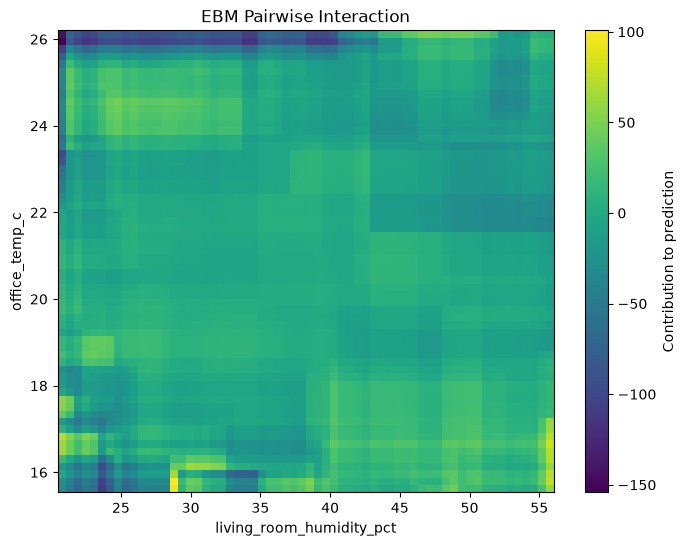

Displayed interaction: living_room_humidity_pct & office_temp_c


In [25]:
if len(interaction_importance) > 0:

    strongest_interaction = (
        interaction_importance.index[0]
    )

    interaction_index = (
        ebm_interaction_demo
        .term_names_
        .index(strongest_interaction)
    )

    global_explanation = (
        ebm_interaction_demo
        .explain_global()
    )

    interaction_data = (
        global_explanation
        .data(interaction_index)
    )

    x_values = interaction_data["left_names"]
    y_values = interaction_data["right_names"]
    scores = interaction_data["scores"]

    plt.figure(figsize=(8, 6))

    plt.imshow(
        scores,
        aspect="auto",
        origin="lower",
        extent=[
            min(x_values),
            max(x_values),
            min(y_values),
            max(y_values),
        ],
    )

    plt.colorbar(
        label="Contribution to prediction"
    )

    plt.xlabel(
        strongest_interaction.split(" & ")[0]
    )
    plt.ylabel(
        strongest_interaction.split(" & ")[1]
    )
    plt.title(
        "EBM Pairwise Interaction"
    )

    plt.show()

    print(
        "Displayed interaction:",
        strongest_interaction,
    )

### How to interpret the heatmap safely

The visualization tells us:

> The fitted demonstration model learned a joint predictive pattern for these variables.

It does **not** prove:

- that the physical variables truly interact in the household,
- that one causes the other,
- or that the interaction will generalize.

In fact, the grouped validation result already told us that adding these interactions did **not** improve prediction here.

**Key takeaway:** Interesting-looking model structure is not the same as validated useful structure.

## 9. Random Forest — A Black-Box Benchmark

Until now, the main models have had structures that can be inspected directly.

A Random Forest combines many decision trees. This provides strong nonlinear flexibility and allows many implicit interactions, but the complete ensemble is no longer something a person can realistically simulate or inspect as one coherent decision process.

We use Random Forest for one specific purpose:

> **If we give up intrinsic model transparency, how much predictive benefit do we gain?**

A poorly regularized forest can overfit, so we should not compare GAM against an obviously overfit black box.

The next block tunes `min_samples_leaf` using the same grouped cross-validation framework.

Larger leaf sizes prevent trees in the forest from forming extremely specific regions and therefore act as regularization.

We intentionally tune only one important complexity control. This notebook is about interpretable-model design, not squeezing every last fraction of performance from a black-box model.

In [26]:
rf_search = GridSearchCV(
    estimator=RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_grid={
        "min_samples_leaf": [
            20,
            50,
            100,
            150,
            200,
        ],
    },
    scoring="neg_root_mean_squared_error",
    cv=group_cv,
    n_jobs=-1,
)

rf_search.fit(
    X_train,
    y_train,
    groups=train_groups,
)

random_forest = rf_search.best_estimator_

print(
    "Selected parameters:",
    rf_search.best_params_,
)

Selected parameters: {'min_samples_leaf': 100}


Grouped validation selects **`min_samples_leaf = 100`**.

The next block compares training and test performance. This helps us check whether the regularized forest still shows a large generalization gap.

In [27]:
rf_predictions = random_forest.predict(
    X_test
)

rf_results = regression_metrics(
    y_test,
    rf_predictions,
)

rf_diagnostic = pd.DataFrame({
    "Random Forest — Train": regression_metrics(
        y_train,
        random_forest.predict(X_train),
    ),
    "Random Forest — Test": rf_results,
}).T

display(
    rf_diagnostic.round(3)
)

,MAE,RMSE,R²
Random Forest — Train,43.307,83.574,0.329
Random Forest — Test,49.787,92.610,0.211


### Random Forest result

The test performance is approximately:

- **MAE = 49.79 Wh**
- **RMSE = 92.61 Wh**
- **R² = 0.211**

The forest is now genuinely competitive rather than artificially weak.

Its MAE is excellent, while its RMSE is very close to the GAM.

This creates a much more useful explainability question than simply saying “black boxes are better” or “interpretable models are better.”

**Key idea:** A fair interpretability comparison requires a credible alternative model. We should not make the transparent model look good by comparing it with a badly tuned black box.

### Why stop tuning here?

We could tune tree depth, feature subsampling, the number of estimators, and several other Random Forest parameters.

We deliberately stop because that would move the notebook away from its learning objective.

The benchmark is already credible enough to ask the important question:

> **Is the predictive benefit of the less transparent model large enough to justify losing intrinsic inspectability?**

## 10. Final Comparison — Performance Is Only Half the Decision

The next table is generated from the models actually fitted above. The values are not hard-coded.

We sort by RMSE because RMSE was defined as our primary metric, but do not interpret the table as a universal ranking of model quality.

In [28]:
final_results = {
    "Mean Baseline": mean_baseline_results,
    "Linear Regression": linear_results,
    "One-SE Lasso": lasso_sparse_results,
    "Small Tree": small_tree_results,
    "GAM": gam_results,
    f"EBM ({selected_interactions} interactions)": ebm_results,
    "Random Forest": rf_results,
}

final_comparison = pd.DataFrame(
    final_results
).T

display(
    final_comparison
    .sort_values("RMSE")
    .round(3)
)

,MAE,RMSE,R²
GAM,51.594,91.971,0.222
Random Forest,49.787,92.610,0.211
Linear Regression,53.887,94.369,0.181
Small Tree,49.981,95.340,0.164
One-SE Lasso,53.323,97.442,0.127
EBM (0 interactions),63.334,101.651,0.050
Mean Baseline,61.341,104.325,-0.001


### What does the final table tell us?

With this fixed evaluation split:

- **GAM** has the lowest RMSE at about **91.97**.
- **Random Forest** is extremely close at about **92.61** and has the lowest MAE.
- **Linear Regression** performs surprisingly well given its simplicity.
- **Small Tree** has strong MAE but somewhat worse RMSE.
- **One-SE Lasso** sacrifices some predictive performance in exchange for only 5 active features.
- **EBM** performs weakly in this particular configuration.
- all useful models beat the mean baseline on RMSE.

The difference between GAM and Random Forest is small. We have **not** performed a statistical test showing that this gap is meaningful, so it would be too strong to declare GAM definitively superior.

A better statement is:

> **GAM and Random Forest show comparable predictive performance under this evaluation, but they offer very different levels of direct model inspectability.**

Performance metrics alone do not describe interpretability.

The next table summarizes structural properties of the model families: whether the fitted structure is directly inspectable, whether nonlinear effects are available, how interactions are represented, and what kind of complexity threatens human understanding.

These are **not interpretability scores**. Interpretability depends on the actual fitted model, the audience, and the decision being supported.

In [29]:
model_properties = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "One-SE Lasso",
        "Small Tree",
        "GAM",
        "EBM",
        "Random Forest",
    ],
    "Directly inspectable structure": [
        "Yes",
        "Yes",
        "Yes, while small",
        "Yes",
        "Yes",
        "No, not as a whole",
    ],
    "Nonlinear effects": [
        "No",
        "No",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
    ],
    "Interactions": [
        "No",
        "No",
        "Yes, through splits",
        "No explicit pairwise terms",
        "Optional pairwise terms",
        "Many implicit interactions",
    ],
    "Main complexity concern": [
        "Many coefficients",
        "Feature-selection stability",
        "Tree size",
        "Wiggly shape functions",
        "Number of terms/interactions",
        "Ensemble complexity",
    ],
})

display(model_properties)

,Model,Directly inspectable structure,Nonlinear effects,Interactions,Main complexity concern
0,Linear Regression,Yes,No,No,Many coefficients
1,One-SE Lasso,Yes,No,No,Feature-selection stability
2,Small Tree,"Yes, while small",Yes,"Yes, through splits",Tree size
3,GAM,Yes,Yes,No explicit pairwise terms,Wiggly shape functions
4,EBM,Yes,Yes,Optional pairwise terms,Number of terms/interactions
5,Random Forest,"No, not as a whole",Yes,Many implicit interactions,Ensemble complexity


### The central design question

Suppose you are presenting this model to a building-energy analyst who wants to inspect learned relationships.

Would you prefer:

- the GAM, whose nonlinear feature functions can be inspected directly, or
- the Random Forest, whose prediction performance is very similar but whose full internal reasoning is not directly manageable?

There is no rule saying that the interpretable model must always be chosen.

The point is that **model choice should reflect both predictive requirements and explanation requirements**.

If the Random Forest had dramatically lower error, the trade-off would look different. In this case, the predictive gap is small enough that interpretability becomes a genuinely relevant design consideration.

## 11. Final Decision Exercise

Imagine that you are the analyst responsible for recommending one model to the building-energy research team.

Do not choose by looking at one metric only.

Use evidence from the notebook to consider:

- predictive error,
- typical errors versus large errors,
- number of active model components,
- human simulatability,
- visibility of nonlinear relationships,
- interaction complexity,
- negative-control behavior,
- physical validity of predictions,
- and the stakeholder's need to inspect the model.

### Questions

1. Which model would you recommend for this stakeholder, and why?
2. What evidence would make you change that recommendation?
3. Is the five-feature Lasso simple enough to justify its higher RMSE?
4. At what point did the Decision Tree stop feeling realistically simulatable?
5. What did GAM add that Linear Regression could not represent?
6. Why did we validate interactions before interpreting them?
7. What did `random_control` teach us about visible patterns?
8. Why do the negative GAM predictions matter?
9. Which conclusions in this notebook describe **model behavior**, and which tempting causal conclusions would be unjustified?

## What should you now understand?

After completing this case, you should be able to explain why:

- a simple linear model is an important first baseline,
- transparency alone does not guarantee cognitive simplicity,
- sparsity creates a real performance–simplicity trade-off,
- Decision Trees become less interpretable as their structure grows,
- GAMs add nonlinear flexibility while preserving feature-level inspection,
- GA2M-style interactions should be selected only when they add value,
- a black-box model does not automatically outperform an interpretable one,
- model explanations describe learned predictive behavior rather than causal truth,
- and model selection is ultimately a **decision-design problem**, not just an optimization contest.

### Core takeaway

> **Start simple. Add complexity only when the additional complexity contributes enough value to justify its cost.**

Interpretability is not a label attached to an algorithm name. It depends on the model's structure, size, representation, stakeholder, and intended decision.

## Selected references

- Candanedo, L. M., Feldheim, V., & Deramaix, D. (2017). *Data driven prediction models of energy use of appliances in a low-energy house*. Energy and Buildings, 140, 81–97.
- Hastie, T., & Tibshirani, R. (1990). *Generalized Additive Models*. Chapman & Hall.
- Lou, Y., Caruana, R., & Gehrke, J. (2012). *Intelligible Models for Classification and Regression*. KDD.
- Caruana, R. et al. (2015). *Intelligible Models for HealthCare: Predicting Pneumonia Risk and Hospital 30-day Readmission*. KDD.

Dataset lineage: UCI **Appliances Energy Prediction** dataset.


## Optional Extension — What If We Truly Predict the Future?

The main experiment holds out complete days across the full study period because our goal is to compare model families under a stable teaching setup.

A different deployment question would require a different evaluation design:

> Train only on earlier months and predict a genuinely later period.

In our exploratory work, that chronological design created substantial seasonal covariate shift and forced some models to extrapolate outside the ranges seen during training.

That is valuable, but it answers a different question.

The extension would teach another important lesson:

> **Interpretability does not protect a model from distribution shift.**

We keep that issue outside the core notebook so the main Chapter 2 story remains focused on interpretable model design.